In [1]:
from src.Elements import Elements
from torchview import draw_graph
import graphviz 
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import ViTConfig, ViTModel


class XRFAutoencoder(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
         
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.LazyLinear(256),
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            # nn.LazyLinear(256),
            # nn.ReLU(),
            # nn.LazyLinear(256),
            # nn.ReLU(),
            nn.Unflatten(1, (1, 256)),
            nn.LazyConv1d(256, 1),
            nn.ConvTranspose1d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            # nn.ReLU(),
            nn.ConvTranspose1d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            # nn.ReLU(),
            nn.ConvTranspose1d(64, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            # nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        z = self.encoder(x)

        y = F.sigmoid(z)

        minus_infinity_mask = (y < 0.5).bool()
        z = F.softmax(z.masked_fill(minus_infinity_mask, -1e9), dim=1)
        
        x_prime = self.decoder(z)
        return x_prime, y, z
    

model = XRFCNNClassifier(latent_dim=len(Elements.LINES)).to(device)
# print()
print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
# a = 1
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

graphviz.set_jupyter_format('png')
graph = draw_graph(model, input_size=(64, 1, 4096))


torch.Size([64, 1, 4096])
torch.Size([64, 256])
torch.Size([64, 256])
Sequential(
  (0): Linear(in_features=16, out_features=256, bias=True)
  (1): Unflatten(dim=1, unflattened_size=(1, 256))
  (2): LazyConv1d(0, 256, kernel_size=(1,), stride=(1,))
  (3): ConvTranspose1d(256, 128, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  (4): ConvTranspose1d(128, 64, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  (5): ConvTranspose1d(64, 16, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  (6): ConvTranspose1d(16, 1, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
  (7): Sigmoid()
)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x256 and 16x256)

: 

In [ ]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X_regression.npy")
y = np.load("data/training_data/artificial/y_regression.npy")
y[y>0] = 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 256)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 256)


In [ ]:
from pathlib import Path
from datetime import datetime 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# class CustomLoss(nn.Module):
#     def __init__(self, alpha=0.5):
#         super(CustomLoss, self).__init__()
#         self.alpha = alpha
#         self.mse_criterion = nn.L1Loss()
#         self.bce_criterion = nn.BCELoss()

#     def forward(self, y_pred, x_pred , y_batch, X_batch):
#         # x_loss = self.mse_criterion(x_pred, X_batch) * (1 - self.alpha) 
#         y_batch[y_batch > 0] = 1
#         y_loss = self.bce_criterion(y_pred, y_batch) * self.alpha
#         return y_loss, 0, 0
#         return y_loss + x_loss, x_loss, y_loss
        
# custom_criterion = CustomLoss(0.5)

# class CustomLossSupervised(nn.Module):
#     def __init__(self):
#         super(CustomLossSupervised, self).__init__()
#         self.bce_criterion = nn.BCELoss()

#     def forward(self, y_pred, y_batch):
#         y_batch[y_batch > 0] = 1
#         y_loss = self.bce_criterion(y_pred, y_batch)
#         return y_loss

custom_criterion = nn.BCELoss() #  CustomLossSupervised()

train_history, valid_history, best_loss, best_weights, f1_scores, accuracies, recalls, precisions = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=custom_criterion, epochs=2, mode="supervised", patience=5)


2025-03-09 11:55:28,450 - Epoch 1/2 started.
2025-03-09 11:55:33,429 - Train Epoch Average Loss: 0.5271
2025-03-09 11:55:33,669 - Validation Loss: 0.5132


[array([1., 0., 0., 1., 0., 0., 1.], dtype=float32), array([0., 1., 1., 1., 0., 0., 0.], dtype=float32), array([0., 0., 1., 0., 1., 0., 1.], dtype=float32), array([0., 1., 0., 1., 0., 0., 1.], dtype=float32), array([0., 1., 0., 1., 0., 1., 0.], dtype=float32), array([0., 0., 1., 0., 0., 1., 1.], dtype=float32), array([1., 0., 1., 0., 0., 0., 1.], dtype=float32), array([0., 0., 0., 1., 0., 1., 1.], dtype=float32), array([0., 1., 0., 0., 1., 0., 1.], dtype=float32), array([0., 1., 1., 0., 0., 1., 0.], dtype=float32), array([1., 1., 0., 0., 1., 0., 0.], dtype=float32), array([1., 0., 0., 0., 0., 0., 0.], dtype=float32), array([0., 1., 0., 0., 1., 0., 1.], dtype=float32), array([1., 1., 0., 0., 0., 0., 1.], dtype=float32), array([0., 0., 0., 1., 1., 0., 1.], dtype=float32), array([0., 1., 0., 0., 0., 1., 0.], dtype=float32), array([0., 1., 1., 0., 0., 0., 1.], dtype=float32), array([0., 0., 1., 0., 1., 1., 0.], dtype=float32), array([1., 1., 1., 0., 0., 0., 0.], dtype=float32), array([0., 

2025-03-09 11:55:34,928 - 
Accuracy       : [                         ] 0.0000
Precision      : [========                 ] 0.3320
Recall         : [=========================] 1.0000
F1 Score       : [============             ] 0.4882
2025-03-09 11:55:34,931 - New best model saved.
2025-03-09 11:55:34,931 - Epoch 1 finished in 6.48 seconds.

2025-03-09 11:55:34,932 - Epoch 2/2 started.


[array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 

2025-03-09 11:55:40,647 - Train Epoch Average Loss: 0.5105
2025-03-09 11:55:40,898 - Validation Loss: 0.5065


[array([0., 1., 1., 0., 1., 0., 0.], dtype=float32), array([0., 1., 0., 1., 1., 0., 0.], dtype=float32), array([0., 0., 1., 0., 1., 0., 0.], dtype=float32), array([0., 1., 0., 1., 1., 0., 0.], dtype=float32), array([1., 0., 0., 0., 1., 1., 0.], dtype=float32), array([0., 0., 0., 0., 0., 1., 1.], dtype=float32), array([1., 0., 0., 0., 0., 0., 1.], dtype=float32), array([0., 1., 0., 0., 0., 1., 0.], dtype=float32), array([1., 0., 0., 0., 0., 1., 1.], dtype=float32), array([0., 0., 0., 0., 1., 1., 0.], dtype=float32), array([0., 1., 0., 0., 0., 1., 1.], dtype=float32), array([0., 0., 1., 0., 0., 0., 0.], dtype=float32), array([0., 0., 0., 1., 0., 0., 0.], dtype=float32), array([1., 1., 0., 0., 0., 0., 0.], dtype=float32), array([1., 0., 0., 1., 0., 0., 1.], dtype=float32), array([1., 0., 0., 0., 1., 0., 0.], dtype=float32), array([1., 1., 0., 1., 0., 0., 0.], dtype=float32), array([0., 1., 0., 1., 0., 0., 0.], dtype=float32), array([0., 0., 1., 1., 0., 0., 1.], dtype=float32), array([1., 

2025-03-09 11:55:42,148 - 
Accuracy       : [                         ] 0.0000
Precision      : [========                 ] 0.3320
Recall         : [=========================] 1.0000
F1 Score       : [============             ] 0.4882
2025-03-09 11:55:42,150 - New best model saved.
2025-03-09 11:55:42,150 - Epoch 2 finished in 7.22 seconds.



[array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 1., 1., 1., 1., 1., 1.], dtype=float32), array([1., 

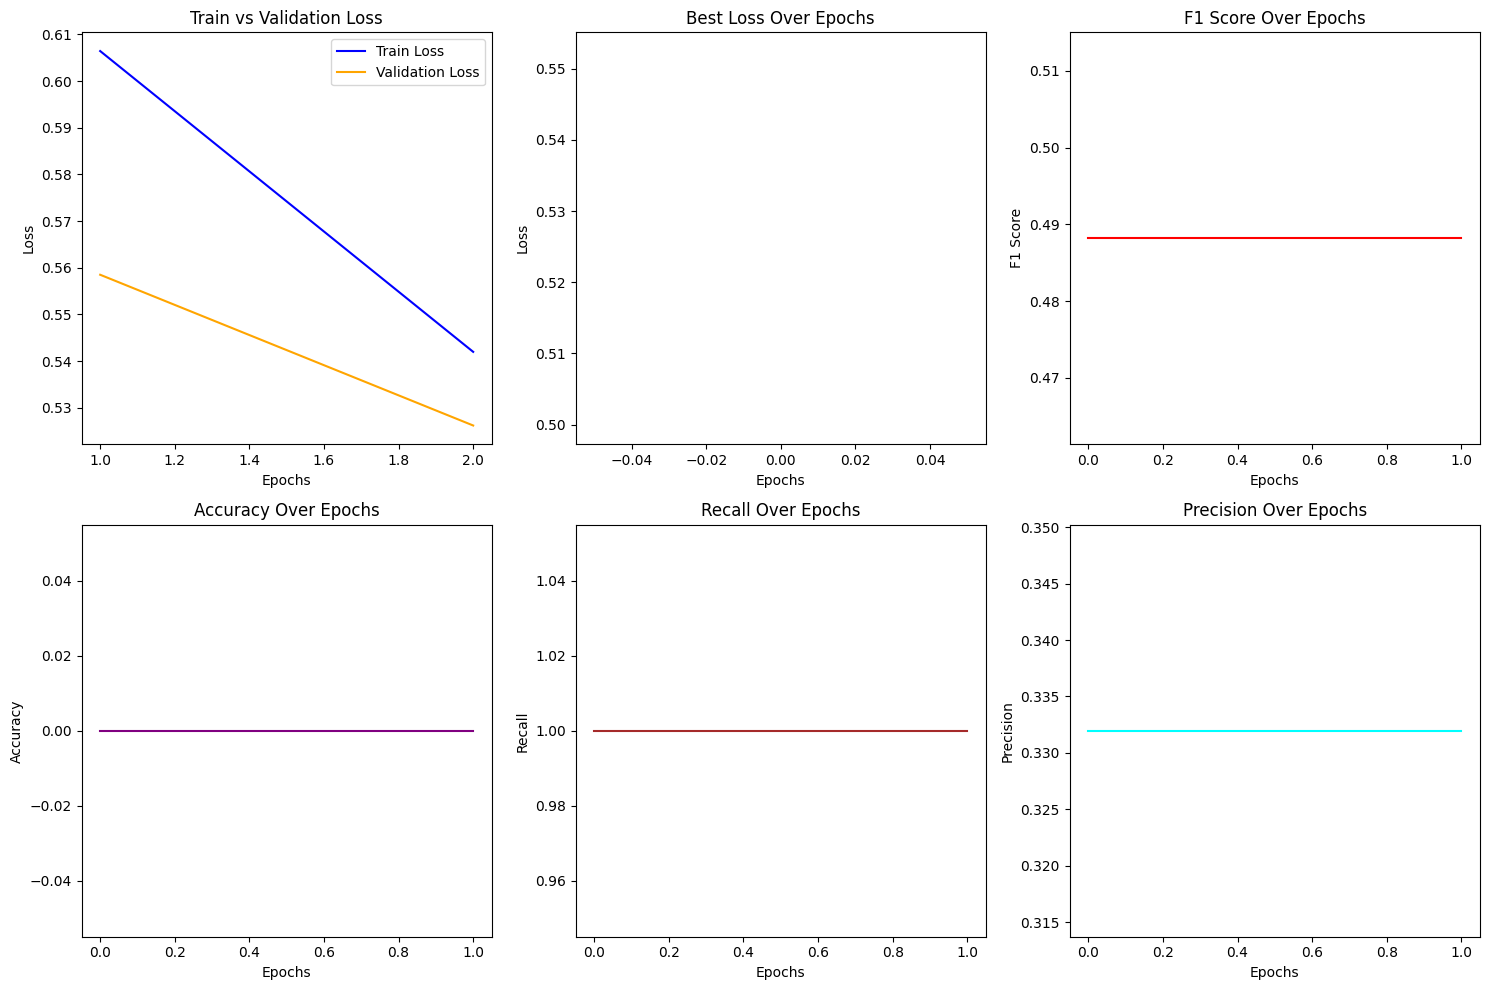

In [ ]:
import matplotlib.pyplot as plt

# Assuming these are lists or arrays representing the values over epochs
epochs = range(1, len(train_history) + 1)  # Assuming length of train_history gives number of epochs

# Create a figure and axes to hold subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# Plot Train and Validation Loss
axs[0, 0].plot(epochs, train_history, label="Train Loss", color="blue")
axs[0, 0].plot(epochs, valid_history, label="Validation Loss", color="orange")
axs[0, 0].set_title("Train vs Validation Loss")
axs[0, 0].set_xlabel("Epochs")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].legend()

# Plot Best Loss
axs[0, 1].plot(best_loss, label="Best Loss", color="green")
axs[0, 1].set_title("Best Loss Over Epochs")
axs[0, 1].set_xlabel("Epochs")
axs[0, 1].set_ylabel("Loss")

# Plot F1 Scores
axs[0, 2].plot(f1_scores, label="F1 Score", color="red")
axs[0, 2].set_title("F1 Score Over Epochs")
axs[0, 2].set_xlabel("Epochs")
axs[0, 2].set_ylabel("F1 Score")

# Plot Accuracy
axs[1, 0].plot(accuracies, label="Accuracy", color="purple")
axs[1, 0].set_title("Accuracy Over Epochs")
axs[1, 0].set_xlabel("Epochs")
axs[1, 0].set_ylabel("Accuracy")

# Plot Recall
axs[1, 1].plot(recalls, label="Recall", color="brown")
axs[1, 1].set_title("Recall Over Epochs")
axs[1, 1].set_xlabel("Epochs")
axs[1, 1].set_ylabel("Recall")

# Plot Precision
axs[1, 2].plot(precisions, label="Precision", color="cyan")
axs[1, 2].set_title("Precision Over Epochs")
axs[1, 2].set_xlabel("Epochs")
axs[1, 2].set_ylabel("Precision")

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()


In [ ]:
MODEL_NAME = "XRFAutoencoder"
torch.save(model.state_dict(), Path(f"weights/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}"))

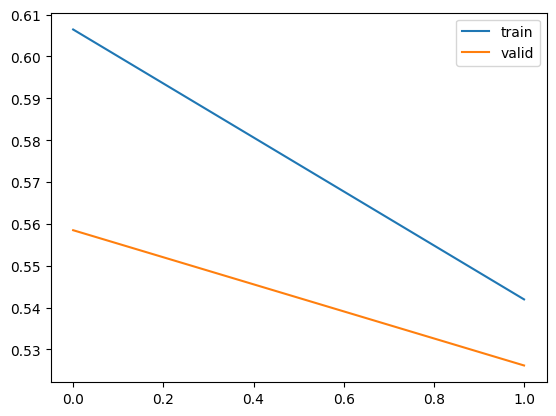

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_history, label="train")
plt.plot(valid_history, label="valid")
plt.legend()


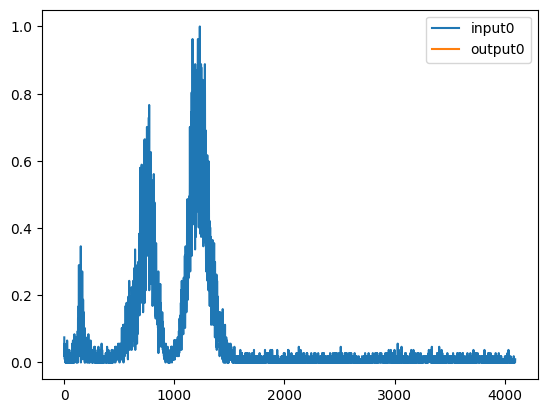

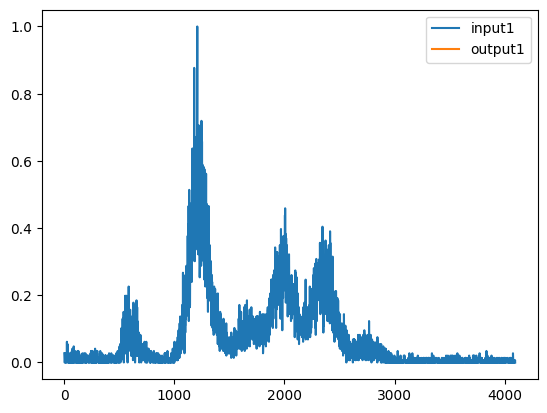

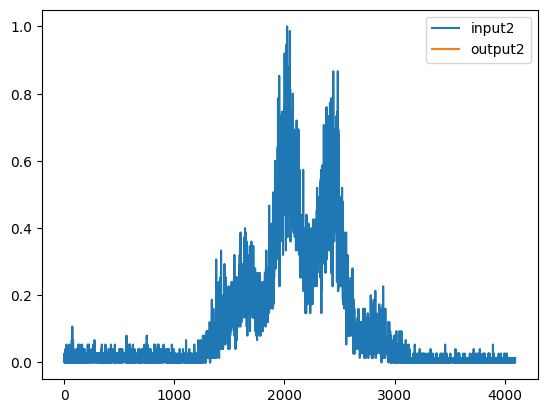

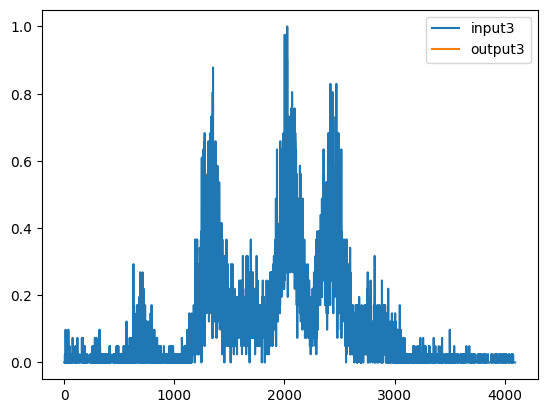

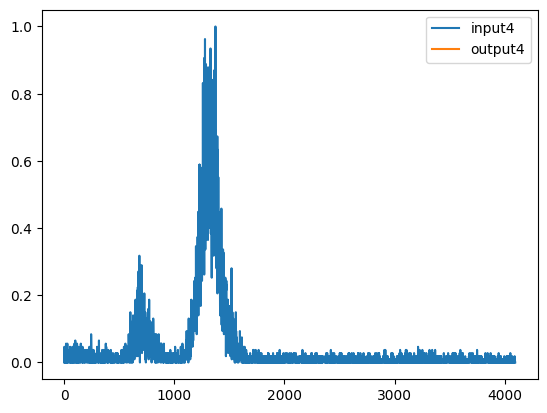

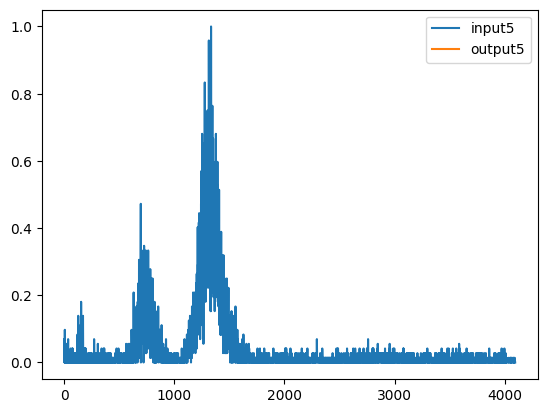

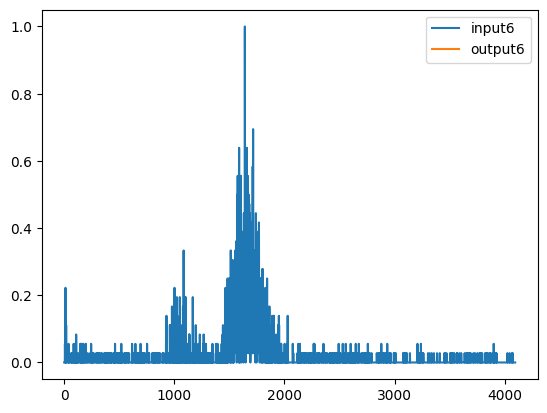

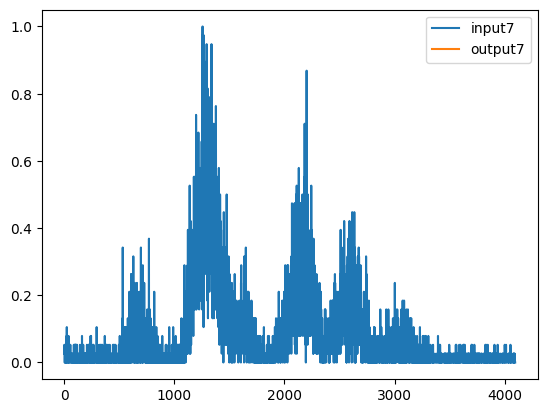

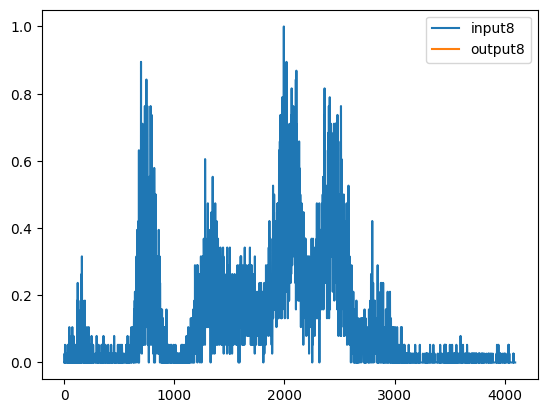

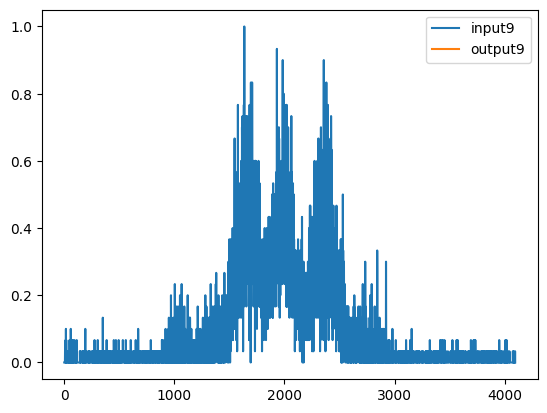

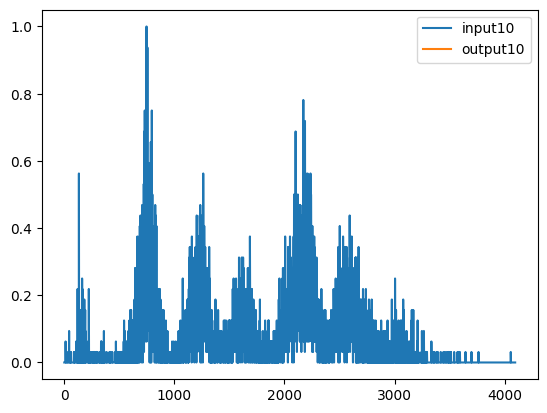

In [ ]:
import matplotlib.pyplot as plt

for i, (X_batch, y_batch) in enumerate(trainloader):
    X_true, y_true = X_batch.cpu().squeeze().detach().numpy()[0], y_batch.cpu().squeeze().detach().numpy()[0]
    X_pred, y_pred = model(X_batch)[0].cpu().squeeze().detach().numpy()[0], model(X_batch)[1].cpu().squeeze().detach().numpy()[0]

    plt.figure(i)
    plt.plot(X_true, label=f"input{i}")
    plt.plot(X_pred, label=f"output{i}")
    plt.legend()
    if i == 10:
        break